# 1D Damped Wave Equation — Dirichlet BCs

## Problem

$$\frac{\partial^2 u}{\partial t^2} + 2\gamma\,\frac{\partial u}{\partial t}
- \frac{\partial^2 u}{\partial x^2} = 0,
\qquad (t,x) \in (0,2) \times (0,1), \qquad \gamma = 0.2$$

**Initial conditions** (two, since the equation is second order in time)

$$u(0,x) = \sin(\pi x), \qquad
\frac{\partial u}{\partial t}\bigg|_{t=0} = -\gamma \sin(\pi x)$$

**Boundary conditions**

$$u(t,0) = 0, \qquad u(t,1) = 0$$

Hyperbolic. A string fixed at both ends, released from a sine displacement,
oscillating against a damping force proportional to velocity. The $2\gamma\,u_t$
term is the PDE analogue of the damped oscillator from Lecture 2.

## Exact solution

$$u_{\text{exact}}(t,x) = e^{-\gamma t}\cos(\omega t)\,\sin(\pi x),
\qquad \omega = \sqrt{\pi^2 - \gamma^2} \approx 3.1352$$

Separable: a fixed spatial shape $\sin(\pi x)$ whose amplitude oscillates at
frequency $\omega$ inside a decaying envelope $e^{-\gamma t}$. Damping both
shrinks the amplitude and shifts the frequency down from $\pi$.

## Method

$$u_\theta(t,x) = e^{-\gamma t}\sin(\pi x)
\;+\; t^2\,\sin(\pi x)\,\mathrm{NN}(\theta; t, x)$$

Verification of all four conditions:

| Condition | Required | Ansatz gives |
|---|---|---|
| $u(0,x)$ | $\sin(\pi x)$ | $\sin(\pi x)$ &nbsp;(second term has $t^2$) |
| $\partial_t u\|_{t=0}$ | $-\gamma\sin(\pi x)$ | $-\gamma\sin(\pi x)$ &nbsp;($t^2$ kills its own derivative too) |
| $u(t,0)$ | $0$ | $0$ &nbsp;($\sin 0 = 0$ in both terms) |
| $u(t,1)$ | $0$ | $0$ &nbsp;($\sin \pi = 0$ in both terms) |

The factor $t^2$ is required rather than $t$: it vanishes at $t=0$ **and** so
does its first derivative, which is what protects both initial conditions.

**Residual**

$$R(t,x) = \frac{\partial^2 u_\theta}{\partial t^2}
+ 2\gamma\,\frac{\partial u_\theta}{\partial t}
- \frac{\partial^2 u_\theta}{\partial x^2}$$

**Loss**

$$\mathcal{L}(\theta) = \frac{1}{NM}\sum_{i=1}^{N}\sum_{j=1}^{M} R(t_i,x_j)^2$$

## Note on the ansatz

Two informed choices were made here:

1. The lift $e^{-\gamma t}\sin(\pi x)$ rather than the minimal Taylor form
   $(1-\gamma t)\sin(\pi x)$ — it satisfies both initial conditions and already
   carries the correct decay envelope.
2. The vanishing factor $\sin(\pi x)$ rather than $x(1-x)$.

Choice 2 makes the whole trial function proportional to $\sin(\pi x)$, i.e.
separable with the correct spatial profile built in. Both are valid, but they
encode knowledge of the solution's structure. Section [N] compares against the
neutral factor $x(1-x)$.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

GAMMA = 0.2
OMEGA = np.sqrt(np.pi**2 - GAMMA**2)
T_max, X_max = 2.0, 1.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("using", device)

using cuda


In [2]:
def grad(y,x):
    return torch.autograd.grad(
        y,x, grad_outputs = torch.ones_like(y), create_graph = True
    )[0]

In [3]:
class WavePINN(nn.Module):
    def __init__(self, width = 64, depth=4):
        super().__init__()
        layers = [nn.Linear(2,width),nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width,width), nn.Tanh()]
        layers += [nn.Linear(width,1)]
        self.net = nn.Sequential(*layers)

    def forward(self,t,x):
        
        nn_out = self.net(torch.cat([t,x],dim=1))

        term1 = torch.exp(GAMMA * -t) * torch.sin(torch.pi * x)
        term2 = (t ** 2) * torch.sin(torch.pi * x) * nn_out

        return term1 + term2

In [4]:
#collocation points
N,M = 256,128
t_lin = torch.linspace(0, T_max, N)
x_lin = torch.linspace(0, X_max, M)
T_grid,X_grid = torch.meshgrid(t_lin, x_lin, indexing='ij')

t_col = T_grid.reshape(-1, 1).to(device).requires_grad_(True)
x_col = X_grid.reshape(-1, 1).to(device).requires_grad_(True)

print(t_col.shape)

torch.Size([32768, 1])


In [5]:
model = WavePINN(width = 64, depth = 4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def compute_loss():
    u = model(t_col,x_col)
    u_t = grad(u, t_col)
    u_tt = grad(u_t, t_col)
    u_x = grad(u, x_col)
    u_xx = grad(u_x, x_col)

    residual = u_tt + 2*GAMMA*u_t - u_xx

    return (residual**2).mean()


In [6]:
import time 

torch.cuda.synchronize()
t0 = time.time()
losses = []

for epoch in range(3000):
    optimizer.zero_grad()
    loss = compute_loss()
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:                                           # ← changed
        losses.append(loss.item()) 
    if epoch % 300 == 0:
        print(f"epoch {epoch:5d}  loss {loss.item():.3e}")

torch.cuda.synchronize() 
pinn_time = time.time()-t0
print(f"trained in {pinn_time:.1f}s")

epoch     0  loss 1.784e+01
epoch   300  loss 1.318e+00
epoch   600  loss 1.016e-01
epoch   900  loss 5.384e-02
epoch  1200  loss 2.642e-02
epoch  1500  loss 1.933e-02
epoch  1800  loss 1.191e+00
epoch  2100  loss 1.008e-02
epoch  2400  loss 7.708e-03
epoch  2700  loss 6.701e-03
trained in 53.7s


In [7]:
with torch.no_grad():
    tt = torch.linspace(0, T_max, 200).reshape(-1, 1)
    xx = torch.linspace(0, X_max, 100).reshape(-1, 1)
    TT, XX = torch.meshgrid(tt.flatten(), xx.flatten(), indexing='ij')
    t_ev = TT.reshape(-1, 1).to(device)                           # ← added .to(device)
    x_ev = XX.reshape(-1, 1).to(device)                           # ← added .to(device)
    u_pred = model(t_ev, x_ev).reshape(200, 100).cpu().numpy()    # ← added .cpu()

u_exact = (np.exp(-GAMMA * TT.numpy())                            # ← all three
           * np.cos(OMEGA * TT.numpy())                           #    lines are
           * np.sin(np.pi * XX.numpy()))                          #    new

pinn_err = np.abs(u_pred - u_exact).max()
print("PINN max error:", pinn_err)

PINN max error: 0.3731217971237928


In [8]:
def fd_damped_wave(nx, T=2.0, s=0.9):
    """
    Explicit finite differences for  u_tt + 2*GAMMA*u_t - u_xx = 0
    on (0,T) x (0,1), u(t,0)=u(t,1)=0.
    s = dt/dx is the Courant number.
    """
    x = np.linspace(0.0, 1.0, nx + 1)
    dx = x[1] - x[0]
    dt = s * dx
    nt = int(round(T / dt))
    dt = T / nt                # adjust so we land exactly on T
    s = dt / dx

    # ---- start-up ----
    u_prev = np.sin(np.pi * x)                       # u^0, the initial condition
    ut0    = -GAMMA * np.sin(np.pi * x)              # du/dt at t=0
    utt0   = (2*GAMMA**2 - np.pi**2) * np.sin(np.pi * x)   # from the PDE

    u_curr = u_prev + dt*ut0 + 0.5*dt**2*utt0        # u^1 by Taylor
    u_curr[0] = 0.0
    u_curr[-1] = 0.0

    # ---- march ----
    for _ in range(1, nt):
        u_next = np.zeros_like(u_curr)
        u_next[1:-1] = (
            2*u_curr[1:-1]
            - (1 - GAMMA*dt) * u_prev[1:-1]
            + s**2 * (u_curr[:-2] - 2*u_curr[1:-1] + u_curr[2:])
        ) / (1 + GAMMA*dt)
        u_next[0] = 0.0
        u_next[-1] = 0.0
        u_prev, u_curr = u_curr, u_next              # shift the two levels forward

    exact = np.exp(-GAMMA*T) * np.cos(OMEGA*T) * np.sin(np.pi*x)
    return x, u_curr, nt, np.abs(u_curr - exact).max()

In [9]:
print("FD convergence:")
prev = None
for nx in [20, 40, 80, 160]:
    x, u, nt, err = fd_damped_wave(nx)
    ratio = f"{prev/err:.2f}" if prev else "  -"
    print(f"  nx={nx:4d}  steps={nt:5d}  max error={err:.3e}  ratio={ratio}")
    prev = err

FD convergence:
  nx=  20  steps=   44  max error=9.283e-06  ratio=  -
  nx=  40  steps=   89  max error=2.772e-06  ratio=3.35
  nx=  80  steps=  178  max error=7.136e-07  ratio=3.88
  nx= 160  steps=  356  max error=1.809e-07  ratio=3.95


In [10]:
print("\nCFL stability:")
for s in [0.8, 0.9, 1.0, 1.05, 1.1]:
    x, u, nt, err = fd_damped_wave(40, T=2.0, s=s)
    print(f"  s = dt/dx = {s:4.2f}   max error = {err:.3e}")


CFL stability:
  s = dt/dx = 0.80   max error = 5.114e-06
  s = dt/dx = 0.90   max error = 2.772e-06
  s = dt/dx = 1.00   max error = 1.739e-07
  s = dt/dx = 1.05   max error = 1.437e+04
  s = dt/dx = 1.10   max error = 2.359e+10


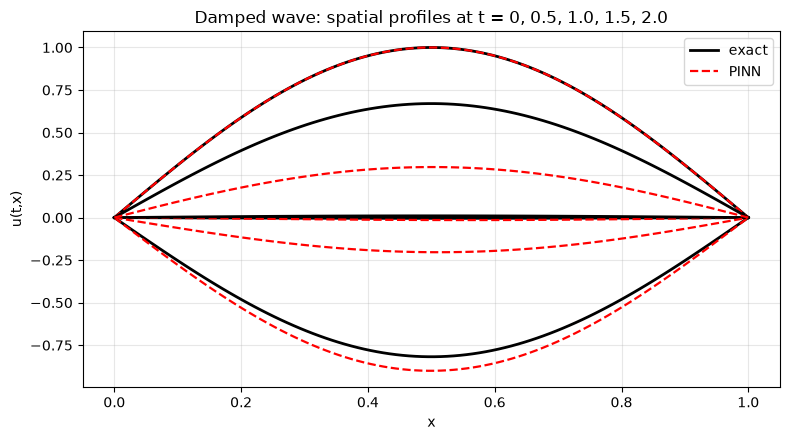

In [11]:
x_np = xx.numpy().flatten()
t_np = tt.numpy().flatten()

snap_idx = [0, 50, 100, 150, 199]

plt.figure(figsize=(8, 4.5))
for k, ti in enumerate(snap_idx):
    plt.plot(x_np, u_exact[ti], 'k-',  lw=2,
             label='exact' if k == 0 else None)
    plt.plot(x_np, u_pred[ti],  'r--', lw=1.6,
             label='PINN'  if k == 0 else None)
plt.xlabel('x'); plt.ylabel('u(t,x)')
plt.title('Damped wave: spatial profiles at t = 0, 0.5, 1.0, 1.5, 2.0')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

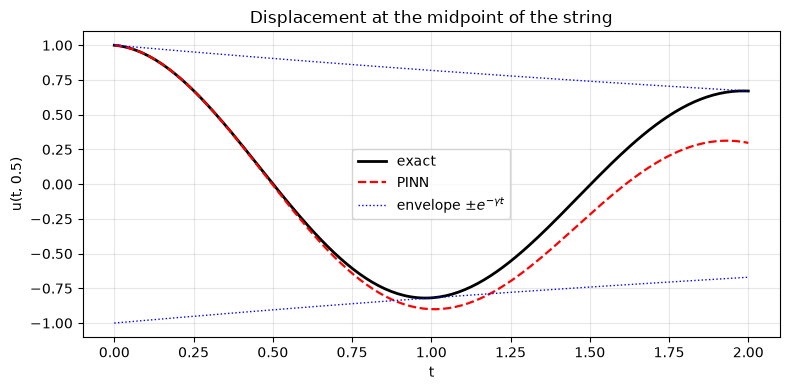

In [12]:
mid = np.argmin(np.abs(x_np - 0.5))     # index nearest x = 0.5

plt.figure(figsize=(8, 4))
plt.plot(t_np, u_exact[:, mid], 'k-',  lw=2,   label='exact')
plt.plot(t_np, u_pred[:, mid],  'r--', lw=1.6, label='PINN')
plt.plot(t_np,  np.exp(-GAMMA*t_np), 'b:', lw=1, label=r'envelope $\pm e^{-\gamma t}$')
plt.plot(t_np, -np.exp(-GAMMA*t_np), 'b:', lw=1)
plt.xlabel('t'); plt.ylabel('u(t, 0.5)')
plt.title('Displacement at the midpoint of the string')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

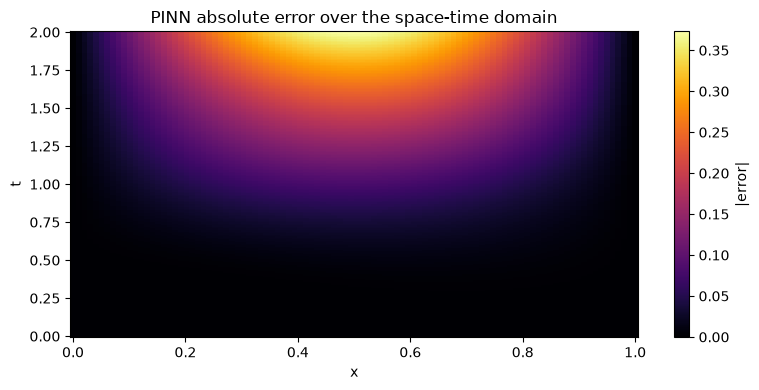

In [13]:
plt.figure(figsize=(8, 4))
plt.pcolormesh(x_np, t_np, np.abs(u_pred - u_exact), shading='auto', cmap='inferno')
plt.colorbar(label='|error|')
plt.xlabel('x'); plt.ylabel('t')
plt.title('PINN absolute error over the space-time domain')
plt.tight_layout(); plt.show()

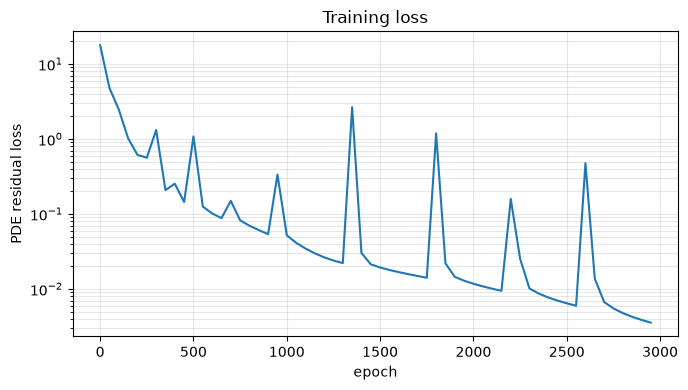

In [14]:
plt.figure(figsize=(7, 4))
plt.semilogy(np.arange(len(losses)) * 50, losses)
plt.xlabel('epoch'); plt.ylabel('PDE residual loss')
plt.title('Training loss')
plt.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

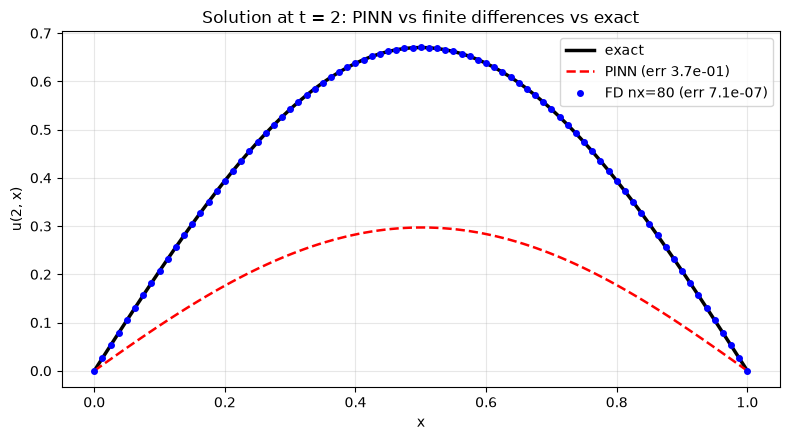

In [15]:
x_fd, u_fd, nt_fd, err_fd = fd_damped_wave(80, T=2.0, s=0.9)

u_ex_T = np.exp(-GAMMA*2.0) * np.cos(OMEGA*2.0) * np.sin(np.pi*x_fd)

plt.figure(figsize=(8, 4.5))
plt.plot(x_fd, u_ex_T,   'k-',  lw=2.5, label='exact')
plt.plot(x_np, u_pred[-1], 'r--', lw=1.8, label=f'PINN (err {pinn_err:.1e})')
plt.plot(x_fd, u_fd,     'bo',  ms=4,   label=f'FD nx=80 (err {err_fd:.1e})')
plt.xlabel('x'); plt.ylabel('u(2, x)')
plt.title('Solution at t = 2: PINN vs finite differences vs exact')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
print("=" * 62)
print(f"{'method':<22}{'max error':>14}{'cost':>26}")
print("-" * 62)
print(f"{'PINN (3000 epochs)':<22}{pinn_err:>14.3e}{f'{pinn_time:.1f} s on GPU':>26}")
print(f"{'FD  (nx=80, s=0.9)':<22}{err_fd:>14.3e}{f'{nt_fd} steps, ~ms on CPU':>26}")
print("=" * 62)
print()
print("Structural differences:")
print("  FD   : provable O(dx^2); requires dt <= dx (CFL); grid values only")
print("  PINN : no convergence theory; no stability constraint;")
print("         closed-form differentiable output, evaluable anywhere")

method                     max error                      cost
--------------------------------------------------------------
PINN (3000 epochs)         3.731e-01             53.7 s on GPU
FD  (nx=80, s=0.9)         7.136e-07     178 steps, ~ms on CPU

Structural differences:
  FD   : provable O(dx^2); requires dt <= dx (CFL); grid values only
  PINN : no convergence theory; no stability constraint;
         closed-form differentiable output, evaluable anywhere
